In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv(r"C:\Users\ACER\OneDrive\Documents\jupyter\Cleaned_Enquiry_Dataset.csv")
data

,Unnamed: 0,name,location,mobile_no,email,find_us,qualification,branch,career_issue,looking_for,...,time_slot,date,attended_by,no_persons,fee_details,year_of_pass_out,status,remarks,year,month
0,0,hidden,ramanattukara,hidden,hidden,google,ug,commerce,no_career_issue,others,...,morning,2020-12-11,deepak,3,35000,2018,not joined,not impressed,2020,12
1,1,hidden,kozhikode,hidden,hidden,google,ug,electronics,no_career_issue,work experience,...,morning,2020-07-12,lekha,2,60000,2016,not joined,not interested,2020,7
2,2,hidden,nadakkavu,hidden,hidden,social media,pg,electronics,no_career_issue,others,...,morning,2020-07-26,baiju,3,60000,2020,not joined,joined other institude,2020,7
3,3,hidden,ramanattukara,hidden,hidden,social media,ug,other,non it background,short term course,...,morning,2020-01-18,baiju,3,35000,2018,not joined,not interested,2020,1
4,4,hidden,westhill,hidden,hidden,social media,ug,computer science,no_career_issue,work experience,...,evening,2020-03-15,rifna,5,60000,2018,not joined,not okay,2020,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1375,1375,hidden,kunnamangalam,hidden,hidden,reference,pg,mechanical,no_career_issue,short term course,...,morning,2025-09-14,baiju,1,60000,2021,joined,not impressed,2025,9
1376,1376,hidden,manjeri,hidden,hidden,google,pg,computer science,career gap,short term course,...,afternoon,2025-07-19,anupama,2,60000,2024,joined,not impressed,2025,7
1377,1377,hidden,kottayam,hidden,hidden,social media,sslc,other,no_career_issue,job oriented course,...,evening,2025-10-22,baiju,3,12500,2022,not joined,not impressed,2025,10
1378,1378,hidden,kondotty,hidden,hidden,reference,ug,civil,career gap,it internship,...,morning,2025-04-19,lekha,1,60000,2020,not joined,joined other institude,2025,4


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1380 entries, 0 to 1379
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1380 non-null   int64 
 1   name              1380 non-null   object
 2   location          1380 non-null   object
 3   mobile_no         1380 non-null   object
 4   email             1380 non-null   object
 5   find_us           1380 non-null   object
 6   qualification     1380 non-null   object
 7   branch            1380 non-null   object
 8   career_issue      1380 non-null   object
 9   looking_for       1380 non-null   object
 10  technology        1380 non-null   object
 11  mode              1380 non-null   object
 12  time_slot         1380 non-null   object
 13  date              1380 non-null   object
 14  attended_by       1380 non-null   object
 15  no_persons        1380 non-null   int64 
 16  fee_details       1380 non-null   int64 
 17  year_of_pass_o

In [4]:
data.duplicated().sum()

np.int64(0)

In [5]:
data.isna().sum()

Unnamed: 0          0
name                0
location            0
mobile_no           0
email               0
find_us             0
qualification       0
branch              0
career_issue        0
looking_for         0
technology          0
mode                0
time_slot           0
date                0
attended_by         0
no_persons          0
fee_details         0
year_of_pass_out    0
status              0
remarks             0
year                0
month               0
dtype: int64

In [6]:
data.columns

Index(['Unnamed: 0', 'name', 'location', 'mobile_no', 'email', 'find_us',
       'qualification', 'branch', 'career_issue', 'looking_for', 'technology',
       'mode', 'time_slot', 'date', 'attended_by', 'no_persons', 'fee_details',
       'year_of_pass_out', 'status', 'remarks', 'year', 'month'],
      dtype='object')

## Defining X and y

In [7]:
feature_cols = [
    'location', 'find_us', 'qualification', 'branch',
    'career_issue', 'looking_for', 'technology', 'mode',
    'time_slot', 'attended_by', 'year_of_pass_out']
X = data[feature_cols].copy()
y = data['status'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature columns:")
print(X.dtypes)

X shape: (1380, 11)
y shape: (1380,)

Feature columns:
location            object
find_us             object
qualification       object
branch              object
career_issue        object
looking_for         object
technology          object
mode                object
time_slot           object
attended_by         object
year_of_pass_out     int64
dtype: object


## Train_Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size : {X_train.shape[0]} samples")
print(f"Testing  set size : {X_test.shape[0]} samples")

Training set size : 1104 samples
Testing  set size : 276 samples


## Label Encoding

In [9]:
categorical_cols = [
    'location', 'find_us', 'qualification', 'branch',
    'career_issue', 'looking_for', 'technology', 'mode',
    'time_slot', 'attended_by'
]

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    le.fit(X[col])
    X_train[col] = le.transform(X_train[col])
    X_test[col]  = le.transform(X_test[col])
    label_encoders[col] = le

le_target = LabelEncoder()
le_target.fit(y)
y_train_enc = le_target.transform(y_train)
y_test_enc  = le_target.transform(y_test)

print("Label encoding complete.")
print(f"Target classes: {le_target.classes_}  →  {list(range(len(le_target.classes_)))}")
X_train.head()

Label encoding complete.
Target classes: ['joined' 'not joined']  →  [0, 1]


,location,find_us,qualification,branch,career_issue,looking_for,technology,mode,time_slot,attended_by,year_of_pass_out
880,11,2,4,5,2,4,2,1,2,1,2022
1025,2,3,5,2,3,0,6,0,2,1,2020
196,15,0,5,2,1,3,1,1,0,7,2018
480,5,3,0,1,3,4,1,1,1,1,2019
1085,20,3,5,0,2,4,1,1,2,1,2022


## Standardisation

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)

X_train_scaled shape: (1104, 11)


## Model Building

### Decision Tree Classifier

In [11]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train_enc)

y_pred_dt = dt_model.predict(X_test)
print("Decision Tree — Training complete.")

Decision Tree — Training complete.


### Random Forest Classifier

In [12]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train_enc)

y_pred_rf = rf_model.predict(X_test)
print("Random Forest — Training complete.")

Random Forest — Training complete.


### K-Nearest Neighbors (KNN)

In [13]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train_enc)

y_pred_knn = knn_model.predict(X_test_scaled)
print("KNN — Training complete.")

KNN — Training complete.


### Logistic Regression

In [14]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train_enc)

y_pred_lr = lr_model.predict(X_test_scaled)
print("Logistic Regression — Training complete.")

Logistic Regression — Training complete.


## Evaluation Metrics

### Decision Tree

=== Decision Tree ===
Accuracy : 0.6377

Classification Report:
              precision    recall  f1-score   support

      joined       0.23      0.26      0.24        62
  not joined       0.78      0.75      0.76       214

    accuracy                           0.64       276
   macro avg       0.50      0.50      0.50       276
weighted avg       0.65      0.64      0.65       276



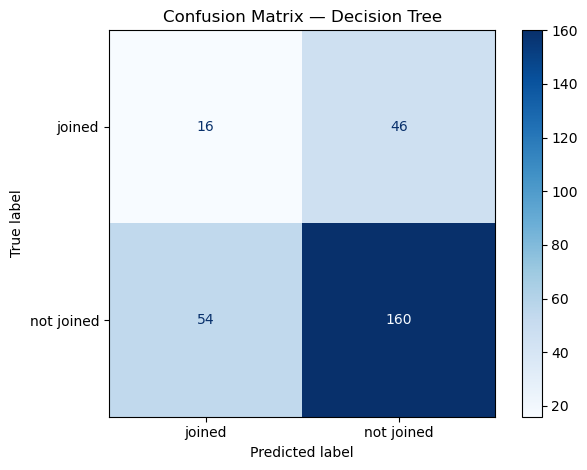

In [15]:
print("=== Decision Tree ===")
print(f"Accuracy : {accuracy_score(y_test_enc, y_pred_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_dt, target_names=le_target.classes_))

cm_dt = confusion_matrix(y_test_enc, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=le_target.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Decision Tree')
plt.tight_layout()
plt.show()

### Random forest

=== Random Forest ===
Accuracy : 0.7717

Classification Report:
              precision    recall  f1-score   support

      joined       0.00      0.00      0.00        62
  not joined       0.77      1.00      0.87       214

    accuracy                           0.77       276
   macro avg       0.39      0.50      0.44       276
weighted avg       0.60      0.77      0.68       276



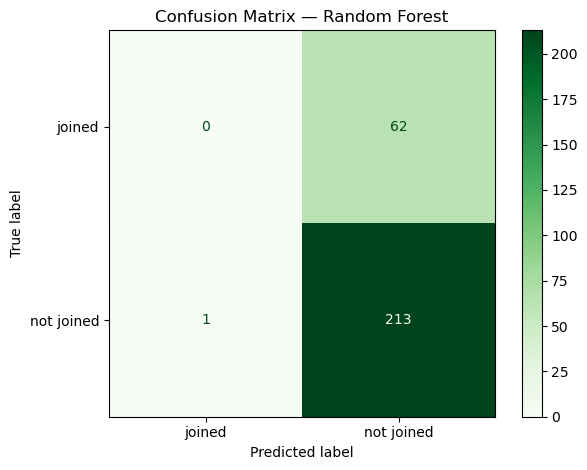

In [16]:
print("=== Random Forest ===")
print(f"Accuracy : {accuracy_score(y_test_enc, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_rf, target_names=le_target.classes_))

cm_rf = confusion_matrix(y_test_enc, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le_target.classes_)
disp.plot(cmap='Greens')
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

### KNN

=== K-Nearest Neighbours ===
Accuracy : 0.7645

Classification Report:
              precision    recall  f1-score   support

      joined       0.41      0.11      0.18        62
  not joined       0.79      0.95      0.86       214

    accuracy                           0.76       276
   macro avg       0.60      0.53      0.52       276
weighted avg       0.70      0.76      0.71       276



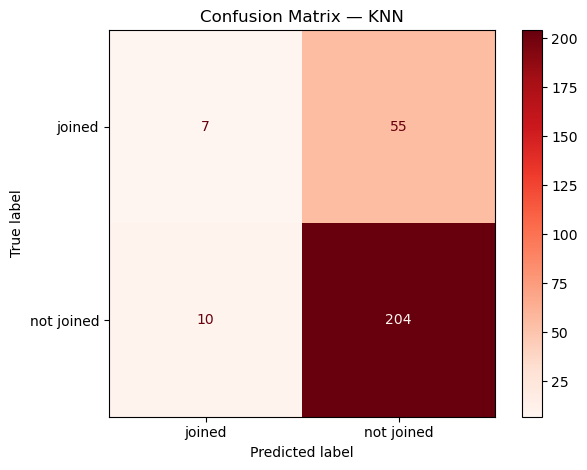

In [17]:
print("=== K-Nearest Neighbours ===")
print(f"Accuracy : {accuracy_score(y_test_enc, y_pred_knn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_knn, target_names=le_target.classes_))

cm_knn = confusion_matrix(y_test_enc, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=le_target.classes_)
disp.plot(cmap='Reds')
plt.title('Confusion Matrix — KNN')
plt.tight_layout()
plt.show()

### Logistic Regression

=== Logistic Regression ===
Accuracy : 0.7754

Classification Report:
              precision    recall  f1-score   support

      joined       0.00      0.00      0.00        62
  not joined       0.78      1.00      0.87       214

    accuracy                           0.78       276
   macro avg       0.39      0.50      0.44       276
weighted avg       0.60      0.78      0.68       276



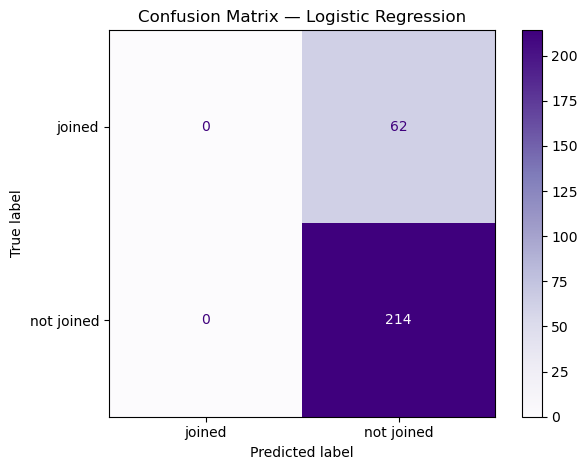

In [18]:
print("=== Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test_enc, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_lr, target_names=le_target.classes_))

cm_lr = confusion_matrix(y_test_enc, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=le_target.classes_)
disp.plot(cmap='Purples')
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

## Comparing Model Accuracy

In [19]:
results = {
    'Decision Tree'      : accuracy_score(y_test_enc, y_pred_dt),
    'Random Forest'      : accuracy_score(y_test_enc, y_pred_rf),
    'KNN'                : accuracy_score(y_test_enc, y_pred_knn),
    'Logistic Regression': accuracy_score(y_test_enc, y_pred_lr)
}

results_df = pd.DataFrame(
    list(results.items()),
    columns=['Model', 'Accuracy']
).sort_values('Accuracy', ascending=False).reset_index(drop=True)

results_df['Accuracy (%)'] = (results_df['Accuracy'] * 100).round(2)
print(results_df.to_string(index=False))

              Model  Accuracy  Accuracy (%)
Logistic Regression  0.775362         77.54
      Random Forest  0.771739         77.17
                KNN  0.764493         76.45
      Decision Tree  0.637681         63.77


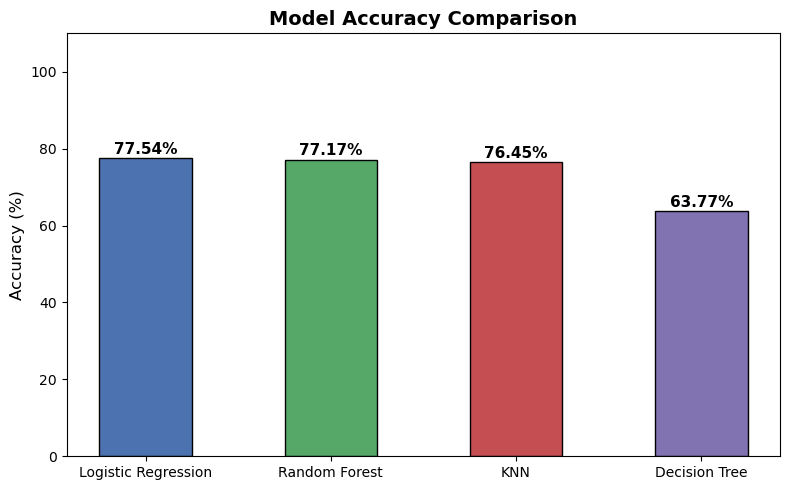

In [20]:
# Bar chart comparison
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

plt.figure(figsize=(8, 5))
bars = plt.bar(results_df['Model'], results_df['Accuracy (%)'], color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, results_df['Accuracy (%)']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{val:.2f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, 110)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()

In [21]:
best_model_name = results_df.iloc[0]['Model']
best_accuracy   = results_df.iloc[0]['Accuracy (%)']

print(f"Best Model  : {best_model_name}")
print(f"Accuracy    : {best_accuracy:.2f}%")

# Map model name to the actual trained model object
model_map = {
    'Decision Tree'      : dt_model,
    'Random Forest'      : rf_model,
    'KNN'                : knn_model,
    'Logistic Regression': lr_model
}

best_model = model_map[best_model_name]

# Flag whether the best model needs scaled input
needs_scaling = best_model_name in ['KNN', 'Logistic Regression']
print(f"Requires Scaling: {needs_scaling}")

Best Model  : Logistic Regression
Accuracy    : 77.54%
Requires Scaling: True


In [22]:
data

,Unnamed: 0,name,location,mobile_no,email,find_us,qualification,branch,career_issue,looking_for,...,time_slot,date,attended_by,no_persons,fee_details,year_of_pass_out,status,remarks,year,month
0,0,hidden,ramanattukara,hidden,hidden,google,ug,commerce,no_career_issue,others,...,morning,2020-12-11,deepak,3,35000,2018,not joined,not impressed,2020,12
1,1,hidden,kozhikode,hidden,hidden,google,ug,electronics,no_career_issue,work experience,...,morning,2020-07-12,lekha,2,60000,2016,not joined,not interested,2020,7
2,2,hidden,nadakkavu,hidden,hidden,social media,pg,electronics,no_career_issue,others,...,morning,2020-07-26,baiju,3,60000,2020,not joined,joined other institude,2020,7
3,3,hidden,ramanattukara,hidden,hidden,social media,ug,other,non it background,short term course,...,morning,2020-01-18,baiju,3,35000,2018,not joined,not interested,2020,1
4,4,hidden,westhill,hidden,hidden,social media,ug,computer science,no_career_issue,work experience,...,evening,2020-03-15,rifna,5,60000,2018,not joined,not okay,2020,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1375,1375,hidden,kunnamangalam,hidden,hidden,reference,pg,mechanical,no_career_issue,short term course,...,morning,2025-09-14,baiju,1,60000,2021,joined,not impressed,2025,9
1376,1376,hidden,manjeri,hidden,hidden,google,pg,computer science,career gap,short term course,...,afternoon,2025-07-19,anupama,2,60000,2024,joined,not impressed,2025,7
1377,1377,hidden,kottayam,hidden,hidden,social media,sslc,other,no_career_issue,job oriented course,...,evening,2025-10-22,baiju,3,12500,2022,not joined,not impressed,2025,10
1378,1378,hidden,kondotty,hidden,hidden,reference,ug,civil,career gap,it internship,...,morning,2025-04-19,lekha,1,60000,2020,not joined,joined other institude,2025,4


## Predicting New Data

In [23]:
# -------------------------------------------------------
# Fill in the new enquiry details here
# -------------------------------------------------------
new_data = pd.DataFrame([{
    'location'        : 'kozhikode',        # replace with actual value
    'find_us'         : 'google', # replace with actual value
    'qualification'   : 'ug',       # replace with actual value
    'branch'          : 'civil',          # replace with actual value
    'career_issue'    : 'career gap',       # replace with actual value
    'looking_for'     : 'it internship',          # replace with actual value
    'technology'      : 'python',       # replace with actual value
    'mode'            : 'offline',      # replace with actual value
    'time_slot'       : 'morning',      # replace with actual value
    'attended_by'     : 'baiju', # replace with actual value
    'year_of_pass_out': 2021            # replace with actual value
}])

# -------------------------------------------------------
# Encode categorical columns using saved encoders
# -------------------------------------------------------
new_data_enc = new_data.copy()

for col in categorical_cols:
    le = label_encoders[col]
    new_data_enc[col] = le.transform(new_data_enc[col])

# -------------------------------------------------------
# Scale if required by the best model
# -------------------------------------------------------
if needs_scaling:
    new_data_input = scaler.transform(new_data_enc)
else:
    new_data_input = new_data_enc

# -------------------------------------------------------
# Predict
# -------------------------------------------------------
prediction_enc   = best_model.predict(new_data_input)
prediction_label = le_target.inverse_transform(prediction_enc)

print(f"Model Used  : {best_model_name}")
print(f"Prediction  : {prediction_label[0]}")

Model Used  : Logistic Regression
Prediction  : not joined
